In [1]:
import os
import cv2
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import BoundaryNorm
from PIL import Image

import torch
from torchvision import transforms
from torch.utils.data import Dataset

In [2]:
def read_part_labels(path):
    with open(path) as f:
        labels = [l.strip() for l in f if l.strip()]
        return labels

def find_part_masks(image_path, class_to_id, mask_dir, labels):
    """Return (class_id, {part_name: mask_path}) or None"""
    image_name = os.path.splitext(os.path.basename(image_path))[0]
    class_name = os.path.basename(os.path.dirname(image_path))
    class_id = class_to_id[class_name]
    class_mask_dir = os.path.join(mask_dir, str(class_id))
    if not os.path.isdir(class_mask_dir):
        return None

    masks = {}
    for f in os.listdir(class_mask_dir):
        if image_name in f:
            for lbl in labels:
                if lbl in f:
                    masks[lbl] = os.path.join(class_mask_dir, f)

    return (class_id, masks) if masks else None


def visualize(*, labels=None, **images):
    """Plot images + masks in one row with perfect discrete colormap legend (unlimited classes)"""
    n = len(images)
    plt.figure(figsize=(4 + 4 * n, 6))  # auto-scale width
    for i, (name, data) in enumerate(images.items(), 1):
        plt.subplot(1, n, i)
        plt.xticks([]); plt.yticks([])
        plt.title(name.replace("_", " ").title(), fontsize=14)
        arr = np.asarray(data)

        # ---------------- IMAGE ----------------
        if name == "image":
            # Handle CHW → HWC
            if arr.ndim == 3 and arr.shape[0] == 3:
                arr = arr.transpose(1, 2, 0)
            # Normalize to 0–1 if needed
            if arr.max() > 1.0:
                arr = arr / 255.0
            plt.imshow(arr)
            continue

        # ---------------- MASK PLOTTING ----------------
        # Supports unlimited integer classes with exact color mapping
        mask = arr.squeeze()  # H x W
        cmap = plt.get_cmap("turbo")  # # Alternatives: "nipy_spectral", "hsv", "jet", "gist_ncar"        
        bounds = np.arange(-0.5, mask.max() + 1.5, 1)
        norm = BoundaryNorm(bounds, cmap.N)
        plt.imshow(mask, cmap=cmap, norm=norm, interpolation="nearest")

        # ---------------- LEGEND ----------------
        # Exact color match between image and legend
        handles = [
            Patch(
                color=cmap(norm(v)),  # exact color used in the image
                label=labels[v] if v < len(labels) else f"Class {v} (unknown)"
            )
            for v in np.unique(mask)
        ]

        plt.legend(
            handles=handles, title="Classes", bbox_to_anchor=(1.05, 1),
            loc="upper left", borderaxespad=0.0, fontsize=10, title_fontsize=12
        )

    plt.tight_layout()
    plt.show()


In [3]:
class PartWholeDataset(Dataset):
    def __init__(self, dataset_path, image_size=320):
        self.image_size = image_size

        # -------- Paths --------
        self.img_dir = os.path.join(dataset_path, "images")
        self.mask_dir = os.path.join(dataset_path, "AnnotationMasksPerclass")

        # -------- Labels --------
        self.labels = ["background"] + read_part_labels(
            os.path.join(dataset_path, "part_labels.txt")
        )
        self.num_parts = len(self.labels)

        # -------- Classes --------
        classes = pd.read_csv(
            os.path.join(dataset_path, "classes.txt"),
            sep=" ", header=None, names=["id", "name"]
        )
        self.class_to_id = {
            name: idx + 1 for idx, name in enumerate(classes["name"])
        }

        # -------- Images --------
        images = pd.read_csv(
            os.path.join(dataset_path, "images.txt"),
            sep=" ", header=None, names=["id", "name"]
        )

        # Build image → (class_id, mask_dict) mapping ONCE
        self.samples = []
        for name in images["name"]:
            img_path = os.path.join(self.img_dir, name)
            info = find_part_masks(
                img_path, self.class_to_id, self.mask_dir, self.labels
            )
            if info:
                self.samples.append((img_path, *info))

        # -------- Transforms --------
        self.img_transform = transforms.Compose([
            transforms.Resize(
                (image_size, image_size),
                interpolation=transforms.InterpolationMode.BILINEAR
            ),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, class_id, mask_dict = self.samples[idx]

        # Load image
        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)

        # Combined mask
        mask = np.zeros((self.image_size, self.image_size), dtype=np.int64)
        for label_idx, label in enumerate(self.labels):
            path = mask_dict.get(label)
            if not path:
                continue

            pm = Image.open(path).convert("L")
            pm = pm.resize((self.image_size, self.image_size), Image.NEAREST)
            mask[np.array(pm) > 127] = label_idx
        mask = torch.from_numpy(mask)
        
        return img, mask, class_id


In [4]:
IMAGE_SIZE = 320
dataset_path = r'/home/c/choton/beemachine/datasets/Others/CUB_200_2011/'

# Paths
imgs_dir = os.path.join(dataset_path, r'images')
mask_dir = os.path.join(dataset_path, r'AnnotationMasksPerclass')
part_label_path = os.path.join(dataset_path, r'part_labels.txt')
classes_path = os.path.join(dataset_path, r"classes.txt")
train_test_path = os.path.join(dataset_path, r"train_test_split.txt")
image_names_path = os.path.join(dataset_path, r"images.txt")

In [5]:
classes_pd = pd.read_csv(classes_path, header=None, sep=" ")
classes_pd.columns = ["id", "name"]
class_names = list(classes_pd['name'])
image_names = pd.read_csv(image_names_path, header=None, sep=" ")
image_names.columns = ["id", "name"]
labels = read_part_labels(part_label_path)
labels.insert(0, 'background')
labels

['background',
 'body',
 'head',
 'neck',
 'beak',
 'tail',
 'right_wing',
 'left_wing',
 'right_leg',
 'left_leg',
 'right_eye',
 'left_eye']

In [6]:
full_dataset = PartWholeDataset(image_size=IMAGE_SIZE, dataset_path=dataset_path)
len(full_dataset)

1888

In [30]:
# ---------------------------------------------------
# Image + Mask Transform Function
# ---------------------------------------------------

def apply_transform(img, mask, transform):
    if transform == "rot90":
        img_t = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        mask_t = cv2.rotate(mask, cv2.ROTATE_90_CLOCKWISE)

    elif transform == "rot180":
        img_t = cv2.rotate(img, cv2.ROTATE_180)
        mask_t = cv2.rotate(mask, cv2.ROTATE_180)

    elif transform == "rot270":
        img_t = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
        mask_t = cv2.rotate(mask, cv2.ROTATE_90_COUNTERCLOCKWISE)

    elif transform == "flip_h":
        img_t = cv2.flip(img, 1)
        mask_t = cv2.flip(mask, 1)

    elif transform == "flip_v":
        img_t = cv2.flip(img, 0)
        mask_t = cv2.flip(mask, 0)

    else:
        img_t = img.copy()
        mask_t = mask.copy()

    return img_t, mask_t

# ---------------------------------------------------
# Overlay Mask Visualization
# ---------------------------------------------------

def overlay_mask(img, mask, alpha=0.5):
    """
    Overlay segmentation mask on image.
    Works for multi-class masks.
    """
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    colored_mask = np.zeros_like(img_rgb)

    unique_vals = np.unique(mask)

    for val in unique_vals:
        if val == 0:
            continue  # background

        color = np.random.randint(0, 255, 3)
        colored_mask[mask == val] = color

    overlay = cv2.addWeighted(img_rgb, 1, colored_mask, alpha, 0)
    return overlay

def to_numpy_image(img):
    """
    Convert PIL / Tensor / numpy image to RGB uint8 numpy (H,W,3)
    """
    if isinstance(img, Image.Image):
        img = np.array(img)
    elif torch.is_tensor(img):
        img = img.detach().cpu()
        # If (C,H,W) → (H,W,C)
        if img.ndim == 3 and img.shape[0] in [1, 3]:
            img = img.permute(1, 2, 0)
        # If float in [0,1] → convert to uint8 properly
        if img.dtype == torch.float32 or img.max() <= 1.0:
            img = (img * 255.0).clamp(0, 255)
        img = img.byte().numpy()
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)
    return img

def to_numpy_mask(mask):
    if isinstance(mask, Image.Image):
        mask = np.array(mask)
    elif torch.is_tensor(mask):
        mask = mask.detach().cpu().numpy()
    return mask.astype(np.uint8)

# ---------------------------------------------------
# Visualization
# ---------------------------------------------------

def visualize_augmentations_overlay(img_tensor, mask_tensor, labels, alpha=0.45, ncols=3):
    img  = to_numpy_image(img_tensor)           # should be uint8 H×W×3 RGB
    mask = to_numpy_mask(mask_tensor)           # integer H×W

    aug_list = [
        ("original",   None),
        ("rot 90°",    "rot90"),
        ("rot 180°",   "rot180"),
        ("rot 270°",   "rot270"),
        ("flip horiz", "flip_h"),
        ("flip vert",  "flip_v"),
    ]

    nrows = (len(aug_list) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    # Prepare discrete colormap (same as your visualize())
    max_label = int(mask.max()) if mask.size > 0 else 0
    bounds = np.arange(-0.5, max_label + 1.5)
    cmap = plt.get_cmap("turbo")
    norm = BoundaryNorm(bounds, cmap.N)

    legend_handles = [
        Patch(color=cmap(norm(v)), label=labels[int(v)] if int(v) < len(labels) else f"cls {int(v)}")
        for v in sorted(np.unique(mask)) if v > 0
    ]

    for i, (title, tf_name) in enumerate(aug_list):
        ax = axes[i // ncols, i % ncols]

        if tf_name is None:
            img_show, mask_show = img.copy(), mask.copy()
        else:
            img_show, mask_show = apply_transform(img, mask, tf_name)

        # ── Create overlay using NumPy (safe & fast) ─────────────────────────────
        overlay = img_show.astype(np.float32)   # important: go to float for blending

        unique_vals = np.unique(mask_show)
        for v in unique_vals:
            if v == 0:
                continue
            # Get color in [0,1] range
            rgba = cmap(norm(v))                # (r,g,b,a) float [0,1]
            color_rgb = (np.array(rgba[:3]) * 255).astype(np.uint8)

            # Create mask for this class
            class_mask = (mask_show == v)

            # Blend only in those pixels
            overlay[class_mask] = (
                overlay[class_mask] * (1 - alpha) +
                color_rgb * alpha
            )

        # Back to uint8 for display
        overlay = np.clip(overlay, 0, 255).astype(np.uint8)

        ax.imshow(overlay)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend
    if legend_handles:
        fig.legend(
            handles=legend_handles,
            title="Parts",
            loc="center right",
            bbox_to_anchor=(1.02, 0.5),
            fontsize=10,
            title_fontsize=11,
            frameon=True
        )
        plt.subplots_adjust(right=0.82)

    plt.tight_layout()
    plt.show()

class_id: 2


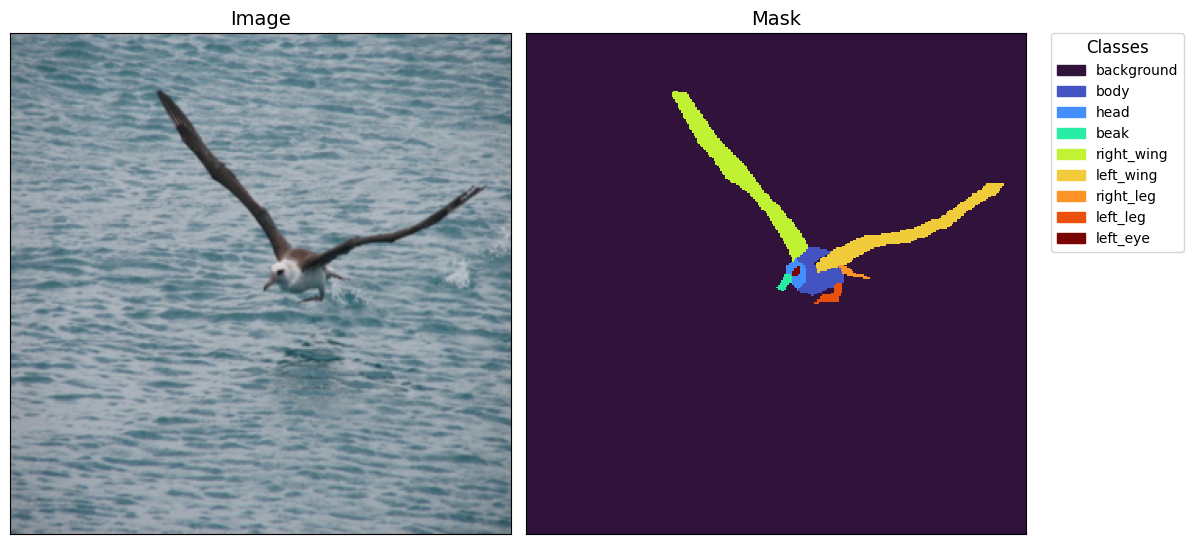

In [18]:
# Get sample image and mask
img, mask, class_id = full_dataset[30]
print(f"class_id: {class_id}")
visualize(labels=full_dataset.labels, image=img, mask=mask)

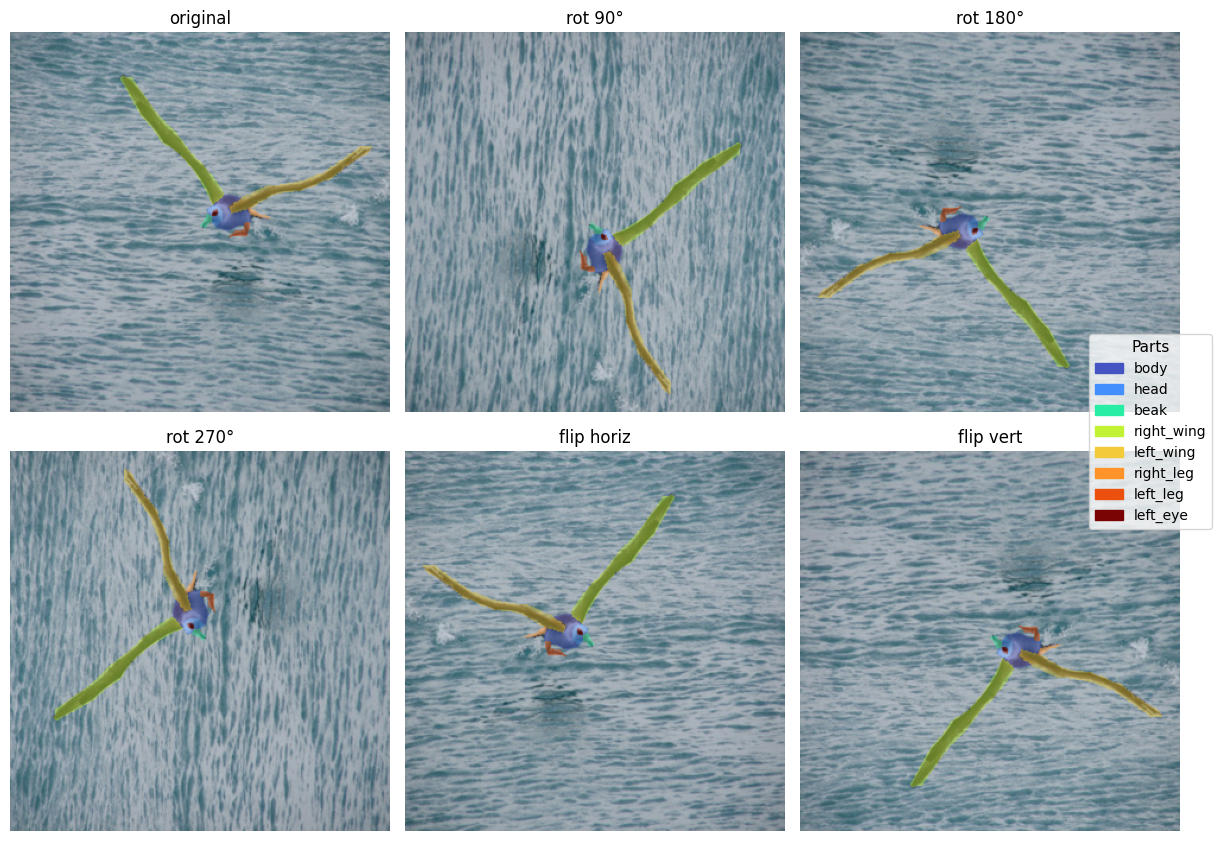

In [31]:
img, mask, class_id = full_dataset[30]
visualize_augmentations_overlay(img, mask, labels=full_dataset.labels, alpha=0.45)

In [32]:
# ---------------------------------------------------
# DATASET-BASED AUGMENTATION (CLASS FOLDER STRUCTURE)
# ---------------------------------------------------

def augment_dataset_from_dataset(dataset,
                                  out_dir,
                                  img_ext=".jpg",
                                  mask_ext="_m.png"):

    out_img_root = os.path.join(out_dir, "aug_images")
    out_mask_root = os.path.join(out_dir, "aug_masks")

    os.makedirs(out_img_root, exist_ok=True)
    os.makedirs(out_mask_root, exist_ok=True)

    transforms_list = [
        ("orig", None),
        ("rot90", "rot90"),
        ("rot180", "rot180"),
        ("rot270", "rot270"),
        ("flip_h", "flip_h"),
        ("flip_v", "flip_v"),
    ]

    print(f"Found {len(dataset)} samples in dataset")

    for idx in tqdm(range(len(dataset))):

        img, mask, class_id = dataset[idx]

        # Convert to numpy
        img = to_numpy_image(img)
        mask = to_numpy_mask(mask)

        # Convert class_id → class_name
        # class_id starts from 1 in your dataset
        class_name = class_names[class_id - 1]

        # Create class folders
        out_img_dir = os.path.join(out_img_root, class_name)
        out_mask_dir = os.path.join(out_mask_root, class_name)

        os.makedirs(out_img_dir, exist_ok=True)
        os.makedirs(out_mask_dir, exist_ok=True)

        base_name = f"{idx:06d}"

        for suffix, tf in transforms_list:

            if tf is None:
                img_t, mask_t = img, mask
            else:
                img_t, mask_t = apply_transform(img, mask, tf)

            out_img_path = os.path.join(
                out_img_dir, f"{base_name}_{suffix}{img_ext}"
            )

            out_mask_path = os.path.join(
                out_mask_dir, f"{base_name}_{suffix}{mask_ext}"
            )

            # Save image (RGB → BGR for cv2)
            cv2.imwrite(out_img_path, cv2.cvtColor(img_t, cv2.COLOR_RGB2BGR))

            # IMPORTANT: preserve mask integer values exactly
            cv2.imwrite(out_mask_path, mask_t)

    print(
        f"\n✅ Augmentation complete.\n"
        f"Saved images in: {out_img_root}\n"
        f"Saved masks in:  {out_mask_root}\n"
        f"Total expected files: {len(dataset)} x {len(transforms_list)} = {len(dataset)*len(transforms_list)}"
    )

In [33]:
augment_dataset_from_dataset(
    dataset=full_dataset,
    out_dir=r'/home/c/choton/beemachine/datasets/Others/CUB_200_2011/'
)

Found 1888 samples in dataset


  0%|          | 0/1888 [00:00<?, ?it/s]

100%|██████████| 1888/1888 [01:47<00:00, 17.51it/s]


✅ Augmentation complete.
Saved images in: /home/c/choton/beemachine/datasets/Others/CUB_200_2011/aug_images
Saved masks in:  /home/c/choton/beemachine/datasets/Others/CUB_200_2011/aug_masks
Total expected files: 1888 x 6 = 11328
